In [1]:
using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
#using Observers #for TDVP
using JLD2
using ProgressMeter
using Kronecker
using SparseArrays

include(dirname(dirname(@__DIR__))*"\\src\\chain_mapping.jl")
include(dirname(dirname(@__DIR__))*"\\src\\map_calculations.jl")

Main.map_calculations

Correlation matrix propagator


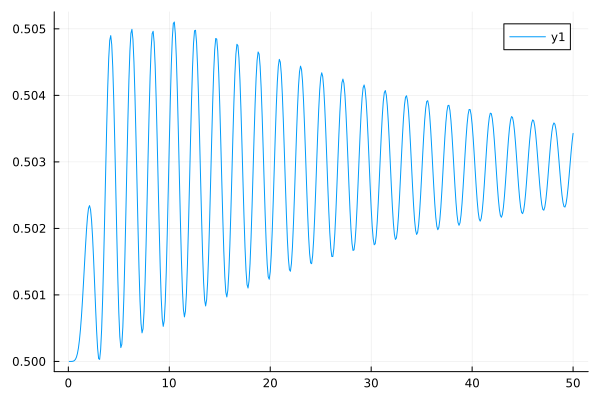

Calculating Λ(t) from the single particle correlation matrix.


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


computing map spectra
computing propagator spectra
norm(map_calculations.expand_Λ(Λ_vec[end], system.N_ring) * map_calculations.vectorise_mat(ρi) - map_calculations.vectorise_mat(ρ_evolved)) = 2.497562774977896e-14


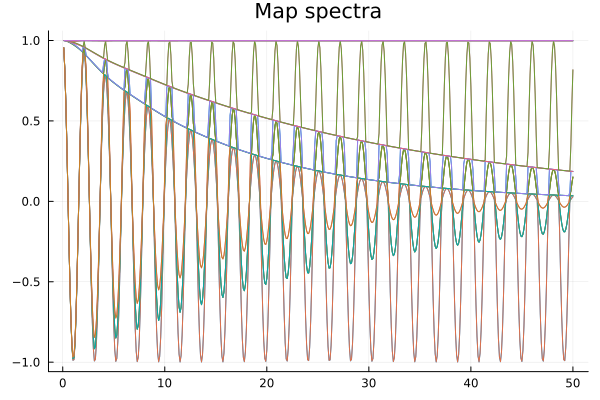

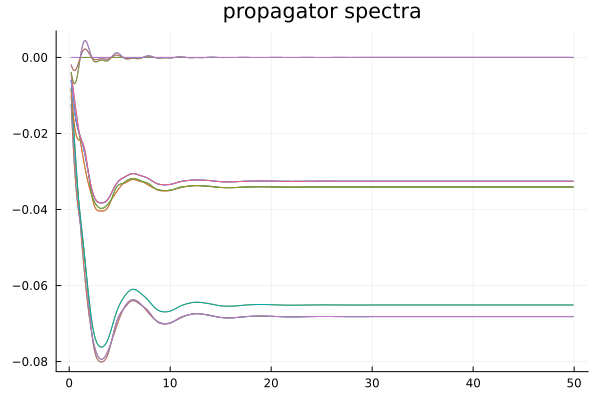

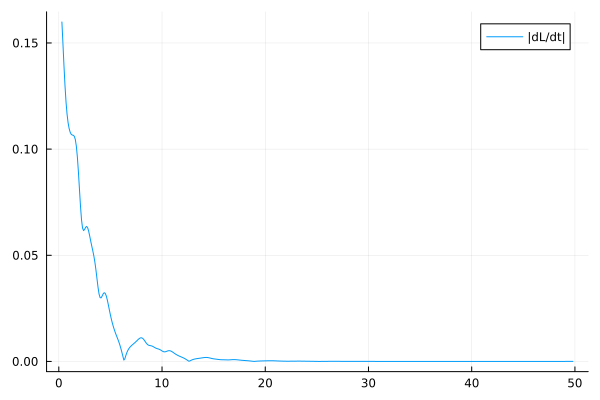

In [8]:

bath = chain_mapping.BathParameters(Γ = 0.1,β = 10.0,μ = 0,D = 1.0,N = 50,spectral_function="smoothed box")

system = chain_mapping.RingParameters(B = 0.5,J = 0.5,N_ring = 3,occupations=[0.2,0.8,0.1], compute_maps_bool = true)

Hsingle,initial_correlation_matrix,sys_anc_inds,system_inds,ancilla_inds = chain_mapping.build_thermofield_ring_model(bath,system);

#evolution parameters
δt = 0.1
T = 50
times = range(δt,stop=T,step=δt)

println("Correlation matrix propagator")
corrs = map_calculations.propagate_correlations(initial_correlation_matrix,Hsingle,times)
den = [corr[1,1] for corr in corrs]
display(Plots.plot(times,real.(den)))


if system.compute_maps_bool
    Λ_vec,L_vec = map_calculations.compute_maps(corrs,δt,sys_anc_inds,ancilla_inds)
    spectra_Λ,spectra_L = map_calculations.compute_spectra(Λ_vec,L_vec)
    propagator_steadystates  = [map_calculations.NESS_extraction(L,"L",system.N_ring) for L in L_vec]
    map_steadystates = [map_calculations.NESS_extraction(Λ,"Λ",system.N_ring) for Λ in Λ_vec]

    dLdt = map_calculations.differentiate(L_vec,δt)

    #map check
    ρi = map_calculations.calculate_ρ_from_correlation_matrix(initial_correlation_matrix,system_inds; eps=1e-14)
    ρ_evolved = map_calculations.calculate_ρ_from_correlation_matrix(corrs[end],system_inds; eps=1e-14)
    @show(norm(map_calculations.expand_Λ(Λ_vec[end],system.N_ring)*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))

    display(Plots.plot(times,real.(spectra_Λ),label=false,title="Map spectra"))
    display(Plots.plot(times[2:end-1],real.(spectra_L),ms=0.1,label=false,title="propagator spectra"))

    display(plot(times[3:end-2],norm.(dLdt),label="|dL/dt|"))
end

In [5]:

# anim = @animate for i=1:length(times)
#     Plots.scatter(real.(spectra_Λ[i,:]),imag.(spectra_Λ[i,:]),
#     xlim=(-1,1),ylim=(-1,1),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"map spectrum1.gif")


# anim = @animate for i=1:length(times)-2
#     Plots.scatter(real.(spectra_L[i,:]),imag.(spectra_L[i,:]),
#     xlim=(-0.25,0.02),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"propagator spectrum2.gif")